In [1]:
import os
import glob
import gc
import random

import numpy as np
import pandas as pd

import jax.numpy as jnp

# If trapezoid doesn’t exist, patch it
if not hasattr(jnp, "trapezoid") and hasattr(jnp, "trapz"):
    jnp.trapezoid = jnp.trapz

import torch

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import scvi

import pegasus as pg
from pegasusio import UnimodalData

import hnoca.snapseed as snap
from hnoca.snapseed.utils import read_yaml
import hnoca.mapping as mapping

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

torch.set_float32_matmul_precision("high")

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [2]:
## Load Dataset ##

# Ref - HNOCA #
hnoca = sc.read_h5ad('/home/deepak/datasets/organoid_atlases/He_Treutlein_2024/bee26cec-e267-420d-aa27-5cbe80389d67.h5ad')
hnoca.layers['raw_counts'] = hnoca.raw.X
del hnoca.raw
gc.collect()

# Ref - Query #
adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata.h5ad')

In [3]:
## Map NCBI Gene Names w/Prasanth's File ##

# load prasanth's annotation file
prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')

# merge prasanth's gene info into the var dataframe
hnoca.var['ensembl_gene_id'] = hnoca.var.index
hnoca.var = hnoca.var.merge(prasanth_annot, left_on='ensembl_gene_id', right_on='ensembl_gene_id', how='left')
hnoca.var.chromosome_name = hnoca.var.chromosome_name.astype('str')

# fix gene name that is NaN
hnoca.var.loc[hnoca.var['hgnc_symbol'].isna(),'hgnc_symbol'] = hnoca.var.loc[hnoca.var['hgnc_symbol'].isna(),'ensembl_gene_id']

#reset the index as the hgnc_symbol
hnoca.var.index = hnoca.var['hgnc_symbol']
hnoca.var.index.name = None

#some ensembls map to same hgnc so we make them unique
hnoca.var_names_make_unique(join='#')

gc.collect()

/tmp/ipykernel_1322196/1717232986.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')


11

In [4]:
## Set Up QC Metrics ##

# filter on robust genes
pg.identify_robust_genes(hnoca, percent_cells=0.05)
hnoca = hnoca[:,hnoca.var['robust']].copy()
gc.collect()

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
hnoca.var["mt"] = hnoca.var_names.str.startswith("MT-")
# ribosomal genes
hnoca.var["ribo"] = hnoca.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
hnoca.var["hb"] = hnoca.var_names.str.contains("^HB[^(P)]")

# add protein_coding genes
hnoca.var['protein_coding'] = hnoca.var['gene_biotype'].apply(lambda x: True if 'protein_coding' == x else False)
hnoca.var['protein_coding'] = hnoca.var['protein_coding'].astype('bool')

# define mitocarta_genes
mitocarta_df = pd.read_csv('/home/deepak/datasets/annotations/Human.MitoCarta3.0.csv')
hnoca.var['mitocarta'] = [True if x in list(mitocarta_df['Symbol']) else False for x in hnoca.var.index]

# define robust_protein_coding genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
hnoca.var['robust_protein_coding'] = hnoca.var['robust'] & hnoca.var['protein_coding']
hnoca.var.loc[hnoca.var.ribo, 'robust_protein_coding'] = False
hnoca.var.loc[hnoca.var.mt, 'robust_protein_coding'] = False
hnoca.var.loc[hnoca.var.mitocarta, 'robust_protein_coding'] = False

# define robust_protein_coding_autosome genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
hnoca.var['autosome'] = hnoca.var.chromosome_name.isin([str(i) for i in range(1,23)])
hnoca.var['robust_protein_coding_autosome'] = hnoca.var['robust_protein_coding'] & hnoca.var['autosome'] 
pg.qc_metrics(UnimodalData(hnoca), mito_prefix='MT-')

2026-03-03 10:26:08,710 - pegasus.tools.preprocessing - INFO - After filtration, 35539/36720 genes are kept. Among 35539 genes, 22146 genes are robust.
2026-03-03 10:26:08,711 - pegasus.tools.preprocessing - INFO - Function 'identify_robust_genes' finished in 53.54s.


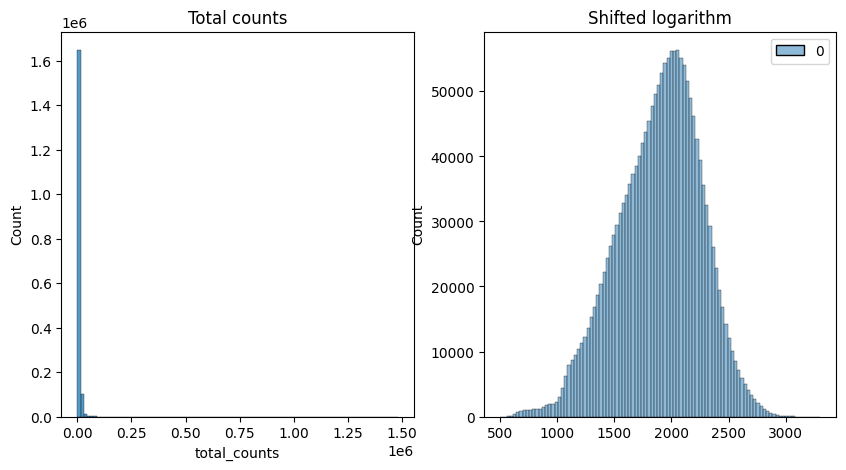

In [5]:
## Log Normalization ##

# normalize 
scales_counts = sc.pp.normalize_total(hnoca, layer='raw_counts', target_sum=None, inplace=False)

# log1p transform
hnoca.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

# set X as log1p normed counts
hnoca.X = hnoca.layers["log1p_norm"]

# recover memory
del scales_counts
gc.collect()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(hnoca.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(hnoca.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

In [6]:
## Batched HVG Selection ##

## Query Work ##
sc.pp.highly_variable_genes(adata, layer='log1p_norm', n_top_genes=4000, inplace=True, subset=True, batch_key='Manuscript')

# calculate HVGs on a protein_coding_autosomal only gene list
sc.pp.highly_variable_genes(hnoca, layer='log1p_norm', n_top_genes=4000, inplace=True, subset=True, batch_key='publication')

# Restrict to Shared Ref-Query HVGs
shared_genes = hnoca.var_names.intersection(adata.var_names[adata.var['highly_variable']])
hnoca = hnoca[:, shared_genes].copy()
print(hnoca.shape)
gc.collect()

(1767674, 2213)


5154

In [7]:
## Setup Model & Begin Training ##

scvi.model.SCVI.setup_anndata(hnoca, layer="raw_counts",     
                              batch_key='batch',
                              categorical_covariate_keys=["publication", 'donor_id', "sex"],
                              continuous_covariate_keys=["total_counts", "total_counts_mt"])

model = scvi.model.SCVI(hnoca, n_hidden=1024, n_latent=30, n_layers=4)

model.train(max_epochs=20, train_size=0.9, early_stopping=True, batch_size=2048)

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:186: UserWarning: Category 172 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/20 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


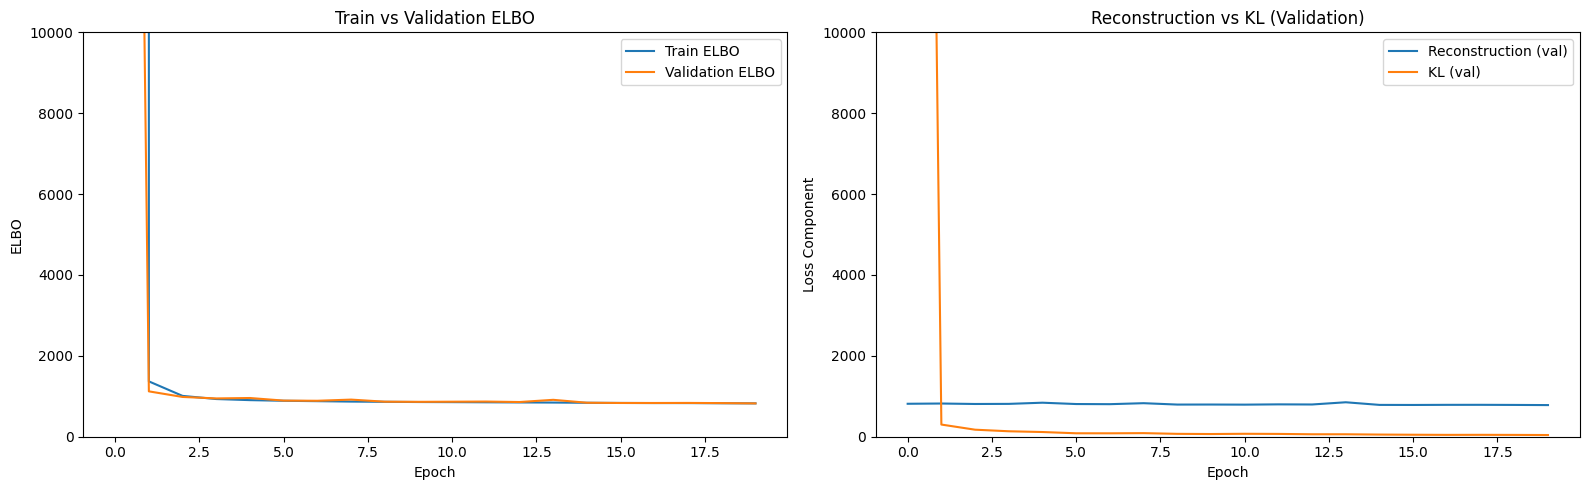

In [8]:
## Examine Train/Val Loss ELBO and Reconstruction/Kullback-Leiber Val Loss

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---- Left plot: Train vs Validation ELBO ----
axes[0].plot(model.history["elbo_train"], label="Train ELBO")
axes[0].plot(model.history["elbo_validation"], label="Validation ELBO")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("ELBO")
axes[0].set_ylim(0, 10000)
axes[0].set_title("Train vs Validation ELBO")
axes[0].legend()

# ---- Right plot: Reconstruction vs KL ----
axes[1].plot(model.history["reconstruction_loss_validation"], label="Reconstruction (val)")
axes[1].plot(model.history["kl_local_validation"], label="KL (val)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss Component")
axes[1].set_ylim(0, 10000)
axes[1].set_title("Reconstruction vs KL (Validation)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
## Save and Loading ##

model_dir = os.path.join("/mnt/sdb/scz_meta_analysis_processed/models/hnoca_models/", "hnoca_scvi")
model.save(model_dir, overwrite=True)

model = scvi.model.SCVI.load(model_dir, adata=hnoca)

INFO     File /mnt/sdb/scz_meta_analysis_processed/models/hnoca_models/hnoca_scvi/model.pt already downloaded      


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:224: UserWarning: Category 172 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


In [11]:
## Save Model Representation ##

hnoca.obsm["X_scVI"] = model.get_latent_representation()
hnoca.layers["scvi_normalized"] = model.get_normalized_expression(library_size=10e4, batch_size=1024)

In [12]:
## Calculate UMAP With scVI Correction ##

# use scVI latent space for UMAP generation
hnoca = UnimodalData(hnoca)
pg.neighbors(hnoca, rep='scVI', use_cache=False, dist='l2', K=50, n_comps=30)
pg.umap(hnoca, rep='scVI', n_neighbors=15, rep_ncomps=30)
hnoca.obsm['X_umap_scVI'] = hnoca.obsm['X_umap']

2026-03-03 11:53:28,009 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 231.69s.
2026-03-03 11:53:47,320 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 19.31s.
2026-03-03 11:53:47,321 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2026-03-03 11:53:47,322 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.
UMAP(min_dist=0.5, n_jobs=1, precomputed_knn=(array([[      0, 1241490, 558948, ..., 230169, 548746, 1759209],
       [      1, 1243850, 155769, ..., 106530, 111351, 545144],
       [      2, 431057, 434875, ..., 132679, 293385, 298362],
       ...,
       [1767671, 1767572, 1767641, ..., 1767379, 1767495, 1767543],
       [1767672, 1767287, 562590, ..., 562525, 562451, 1767650],
       [1767673, 1767605, 1767033, ..., 423134, 1767023, 1195722]]), array([[0.        , 0.4322871 , 0.4890094 , ..., 0.81952864, 0.83560747,
      

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Mar  3 11:53:47 2026 Construct fuzzy simplicial set
Tue Mar  3 11:53:53 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Mar  3 12:28:07 2026 Finished embedding
2026-03-03 12:28:07,884 - pegasus.tools.visualization - INFO - Function 'umap' finished in 2060.56s.


In [ ]:
hnoca_hvg = hnoca_hvg.to_anndata()

In [ ]:
sc.pl.embedding(hnoca_hvg, basis='X_umap_scVI', color=['publication', 'annot_level_2', 'annot_region_rev2', 
                                                        'tissue', 'n_counts', 'percent_mito'], ncols=1)

In [ ]:
## Prep Query for Mapping ##

adata.obs['annot_level_4_rev2'] = 'Unknown'

query_ref = sc.concat([adata, hnoca_hvg], axis=0, join='inner')

In [ ]:
## Train Supervised Part of Model ##

scanvi_model = scvi.model.SCANVI.from_scvi_model(model, adata=query_ref,
                                                 labels_key="annot_level_4_rev2",
                                                 unlabeled_category="Unknown")

scanvi_model.train(max_epochs=20)

In [ ]:
## Get Latent Representation ##

query_ref.obsm['X_scANVI'] = scanvi_model.get_latent_representation(query_ref)